<img src="https://github.com/milena-seismo/DSB-Unit-02/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Visualizing trends

---

### About
Understand how to create charts within `pandas` using the `.plot()` method.

### Learning Objectives
- Chart dates in `pandas`
- Create line charts with `matplotlib`

### Notebook Guide
- Scenario
- Working with dates in `pandas`
- Now You Try!
- Conclusions and Takeaways

# Scenario

You're an analyst working for CoolBricks - a new toy company who wants to compete with LEGO by producing their own bricks and sets. To better understand what kind of sets to create and at what price points, you are tasked with analyzing LEGO's catalogue over time.

The data comes from Kaggle: [https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time](https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time)

We are going to use `pandas` to read this data and `matplotlib` to create plots.

Our research question is: ***How have the number of products changed over time?***

# Working with dates in `pandas`
---

In [5]:
import pandas as pd

In [7]:
lego = pd.read_csv("https://raw.githubusercontent.com/milena-seismo/DSB-Unit-02/refs/heads/main/data/lego.csv")
lego.head()

,Set_ID,Name,Year,Theme,Theme_Group,Subtheme,Category,Packaging,Num_Instructions,Availability,Pieces,Minifigures,Owned,Rating,USD_MSRP,Total_Quantity,Current_Price
0,75-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},16.0,NaN,10.0,0.0,NaN,NaN,NaN
1,77-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},20.0,NaN,11.0,0.0,NaN,NaN,NaN
2,077-1,Pre-School Set,1975,Duplo,Pre-school,NaN,Normal,{Not specified},0,{Not specified},21.0,NaN,10.0,0.0,NaN,0.0,NaN
3,78-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},32.0,NaN,8.0,0.0,NaN,NaN,NaN
4,78-3,Basic Set,1975,Samsonite,Vintage,Basic set,Normal,Box,0,{Not specified},330.0,NaN,10.0,0.0,NaN,0.0,NaN


In [8]:
lego["Year"]

,Year
0,1975
1,1975
2,1975
3,1975
4,1975
...,...
14931,2023
14932,2023
14933,2023
14934,2023


In [9]:
lego.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14936 entries, 0 to 14935
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Set_ID            14936 non-null  object 
 1   Name              14936 non-null  object 
 2   Year              14936 non-null  int64  
 3   Theme             14936 non-null  object 
 4   Theme_Group       14915 non-null  object 
 5   Subtheme          11495 non-null  object 
 6   Category          14936 non-null  object 
 7   Packaging         14936 non-null  object 
 8   Num_Instructions  14936 non-null  int64  
 9   Availability      14936 non-null  object 
 10  Pieces            13133 non-null  float64
 11  Minifigures       7686 non-null   float64
 12  Owned             14771 non-null  float64
 13  Rating            14936 non-null  float64
 14  USD_MSRP          5837 non-null   float64
 15  Total_Quantity    12276 non-null  float64
 16  Current_Price     5442 non-null   float6

In [11]:
pd.to_datetime(lego["Year"])

,Year
0,1970-01-01 00:00:00.000001975
1,1970-01-01 00:00:00.000001975
2,1970-01-01 00:00:00.000001975
3,1970-01-01 00:00:00.000001975
4,1970-01-01 00:00:00.000001975
...,...
14931,1970-01-01 00:00:00.000002023
14932,1970-01-01 00:00:00.000002023
14933,1970-01-01 00:00:00.000002023
14934,1970-01-01 00:00:00.000002023


In [16]:
pd.to_datetime(lego["Year"], format="%Y")

,Year
0,1975-01-01
1,1975-01-01
2,1975-01-01
3,1975-01-01
4,1975-01-01
...,...
14931,2023-01-01
14932,2023-01-01
14933,2023-01-01
14934,2023-01-01


In [21]:
lego["year_data"].dt.year

KeyError: 'year_data'

In [22]:
lego.columns

Index(['Set_ID', 'Name', 'Year', 'Theme', 'Theme_Group', 'Subtheme',
       'Category', 'Packaging', 'Num_Instructions', 'Availability', 'Pieces',
       'Minifigures', 'Owned', 'Rating', 'USD_MSRP', 'Total_Quantity',
       'Current_Price'],
      dtype='object')

In [23]:
lego["year_data"] = pd.to_datetime(lego["Year"], format="%Y")

In [24]:
lego[["Year", "year_data"]].head()

,Year,year_data
0,1975,1975-01-01
1,1975,1975-01-01
2,1975,1975-01-01
3,1975,1975-01-01
4,1975,1975-01-01


In [25]:
lego["year_data"].dt.year

,year_data
0,1975
1,1975
2,1975
3,1975
4,1975
...,...
14931,2023
14932,2023
14933,2023
14934,2023


In [26]:
lego["year_data"].dt.year

,year_data
0,1975
1,1975
2,1975
3,1975
4,1975
...,...
14931,2023
14932,2023
14933,2023
14934,2023


In [30]:
lego.set_index("year_data").head(10)

,Set_ID,Name,Year,Theme,Theme_Group,Subtheme,Category,Packaging,Num_Instructions,Availability,Pieces,Minifigures,Owned,Rating,USD_MSRP,Total_Quantity,Current_Price
year_data,,,,,,,,,,,,,,,,,
1975-01-01,75-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},16.0,NaN,10.0,0.0,NaN,NaN,NaN
1975-01-01,77-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},20.0,NaN,11.0,0.0,NaN,NaN,NaN
1975-01-01,077-1,Pre-School Set,1975,Duplo,Pre-school,NaN,Normal,{Not specified},0,{Not specified},21.0,NaN,10.0,0.0,NaN,0.0,NaN
1975-01-01,78-1,PreSchool Set,1975,PreSchool,Pre-school,NaN,Normal,{Not specified},0,{Not specified},32.0,NaN,8.0,0.0,NaN,NaN,NaN
1975-01-01,78-3,Basic Set,1975,Samsonite,Vintage,Basic set,Normal,Box,0,{Not specified},330.0,NaN,10.0,0.0,NaN,0.0,NaN
1975-01-01,133-1,Locomotive,1975,Trains,Modern day,4.5/12V,Normal,{Not specified},0,{Not specified},87.0,NaN,279.0,0.0,NaN,0.0,NaN
1975-01-01,134-1,Mobile Crane and Wagon,1975,Trains,Modern day,4.5/12V,Normal,Box,0,Retail,86.0,NaN,252.0,0.0,NaN,0.0,NaN
1975-01-01,136-1,Tanker Wagon,1975,Trains,Modern day,4.5/12V,Normal,Box,0,Retail,83.0,NaN,404.0,0.0,NaN,0.0,NaN
1975-01-01,137-2,Passenger Sleeping Car,1975,Trains,Modern day,4.5/12V,Normal,{Not specified},0,{Not specified},82.0,NaN,299.0,0.0,NaN,0.0,NaN


In [32]:
annual_count = (
    lego.set_index("year_data")
    .resample("YS")
    .size()
)

<Axes: xlabel='year_data'>

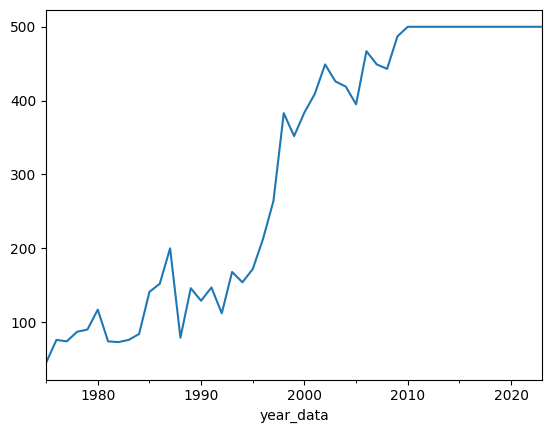

In [33]:
annual_count.plot()

<Axes: title={'center': 'LEGO production'}, xlabel='Year', ylabel='Number of products'>

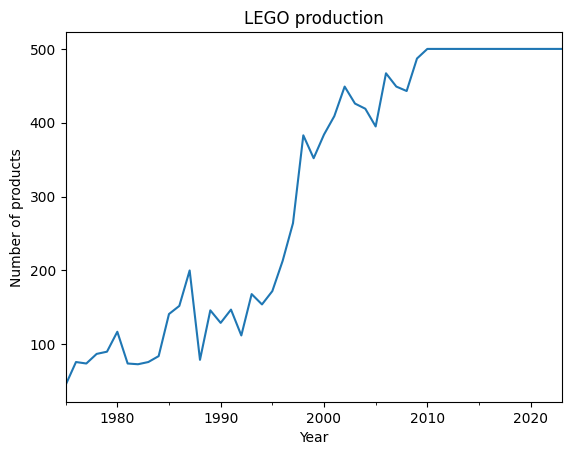

In [35]:
annual_count.plot(
    xlabel="Year",
    ylabel="Number of products",
    title="LEGO production"
)

<Axes: xlabel='year_data'>

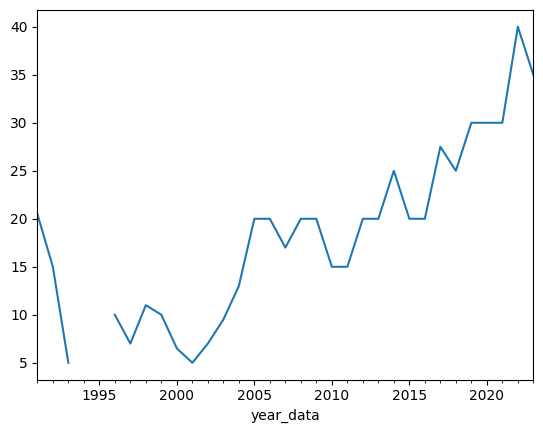

In [37]:
srednja_cijena = (
    lego.dropna(subset=["USD_MSRP"])
    .set_index("year_data")
    .resample("YS")["USD_MSRP"]
    .median()
)

srednja_cijena.plot()

Let's look at the data

We have a "year" column which is an integer, but it could also be a date!

To convert a string to a date we can use the `pandas` `.to_datetime()` method, where we can also specify the format of the date. *See [http://strftime.org/](http://strftime.org/) for more details about datetime formats in Python.*

If we don't specify the format, we get this:

Let's tell `pandas` that the string actually represents the year (and `pandas` will come up with defaults for the month and day)

Great, let's save the "date version" as a new column

Now, we can access date components with the `.dt` accessor

And we have two ways of calculating "products per year". The first is to use the original `Year` column:

Or we can set the `index` of the `DataFrame` to the date column and use `resample` (which is like `groupby` but specifically for dates)

The advantage of `resample` is we get a `Series` that already has a temporal index. This helps with creating line charts with better defaults, for example.

To create a line chart from this data, we can simply call `.plot()` (the default type is a line chart)

As with most plots, we can set some additional values

# Now You Try!
----

1. Create a line chart showing the _**average product retail price**_ over time.

What do you conclude?

How can you improve the chart?

Looks like there is a lot of missing data before the year 2000. We could use that as a cutoff and only visualize data after that year.

2. *BONUS:* Create a new column to calculate the _**decade**_ a product was released. Then calculate the _**average number of pieces per product**_ per decade and plot it as a line chart.

<Axes: xlabel='decade'>

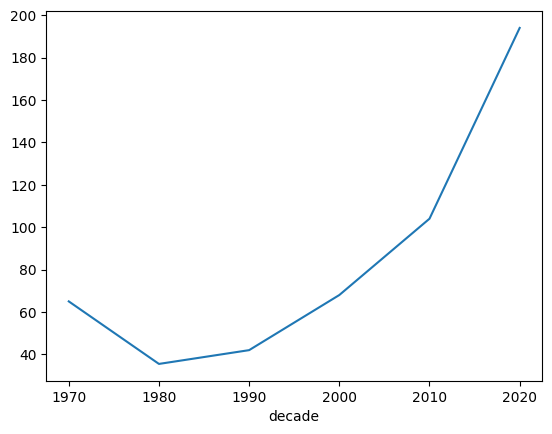

In [39]:
lego["decade"] = lego["Year"].floordiv(10).mul(10)

(
    lego.groupby("decade")["Pieces"].median.plot(

    xlabel = "Decade"
    ,ylabel = "Median number"
    .median()
    .plot()
)

# Conclusions and Takeaways

- `pandas` lets us convert strings to dates with `to_datetime()`
- Once a column is a date, more functionality is available to us
- One use case of date columns is the easier creation of line charts